In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Create Population Ideology


Assuming a republican - leaning precinct with 1000 people. <br>
This is the distribution of ideology of voters in this precinct

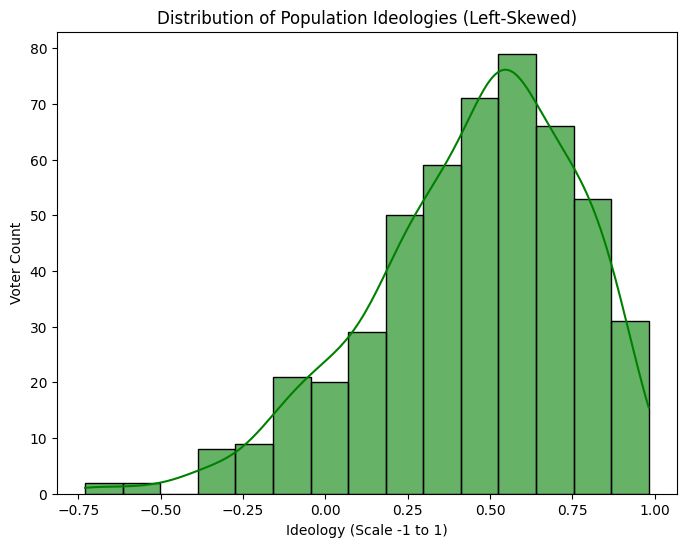

In [3]:
# Generate left-skewed population ideologies
num_total_voters = 500  # Total population size
population_ideologies = np.random.beta(a = 5, b = 2, size=num_total_voters) * 2 - 1  # Scale to -1 to 1

# Plot the distribution of population ideologies
plt.figure(figsize=(8, 6))
sns.histplot(population_ideologies, kde=True, color='green', bins=15, alpha=0.6)
plt.title('Distribution of Population Ideologies (Left-Skewed)')
plt.xlabel('Ideology (Scale -1 to 1)')
plt.ylabel('Voter Count')
plt.show()

In [4]:
population_ideologies

array([ 0.8728781 ,  0.23841275,  0.39622291,  0.51590991,  0.72851297,
        0.20196686,  0.72373454,  0.5074068 ,  0.27544569,  0.83050846,
        0.55694866,  0.02271003,  0.43858349,  0.91212232,  0.61990539,
       -0.21202061,  0.46558874,  0.08950374,  0.00469476,  0.18663109,
        0.36535473,  0.65530373,  0.67197007, -0.37797287,  0.14697321,
        0.11522007,  0.64772993,  0.70462913,  0.68001986,  0.05065162,
        0.45379467,  0.18124462,  0.1968988 ,  0.502993  ,  0.32351137,
        0.58134242,  0.72105981, -0.07626554,  0.55010591,  0.60172728,
        0.32872187,  0.7349008 ,  0.21464113,  0.35908106,  0.17481908,
        0.88835164,  0.16840458,  0.52934633,  0.55716648,  0.1853429 ,
        0.49921849,  0.53360466,  0.56825561,  0.48571172,  0.54234261,
        0.33472694,  0.14397082,  0.55842841,  0.92528747,  0.82460618,
        0.31777775,  0.91019747,  0.19161879,  0.00761535,  0.17499545,
        0.77811838,  0.7395807 ,  0.4146618 , -0.09134369,  0.07

## 2. Primary voters are more extreme

30% show up in the primary election. <br>
70% show up in the general election. <br>
Primary election are selected randomly on the scale of ideology

In [5]:
# 3. Sample 30% of the voters for the general election
num_primary_voters = int(0.3 * num_total_voters)
primary_ideology_indices = np.random.choice(
    np.arange(num_total_voters),
    size=num_primary_voters,
    replace=False
)
primary_ideologies = population_ideologies[primary_ideology_indices]

# 4. Assign votes in each election: ideology ≤ 0 → Democrat, > 0 → Republican
primary_votes = np.where(primary_ideologies <= 0, 'Democrat', 'Republican')


In [6]:
# 3. Sample 70% of the population for the general election
num_general_voters = int(0.7 * num_total_voters)
general_ideology_indices = np.random.choice(
    np.arange(num_total_voters),
    size=num_general_voters,
    replace=False
)
general_ideologies = population_ideologies[general_ideology_indices]
general_votes = np.where(general_ideologies <= 0, 'Democrat', 'Republican')

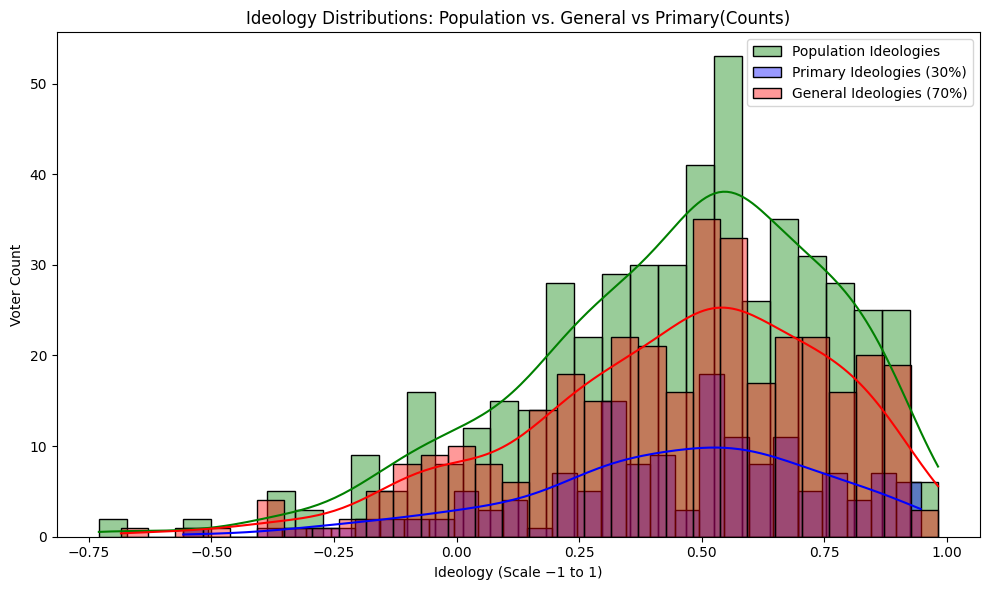

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(population_ideologies, kde=True, bins=30,
             color='green', alpha=0.4, label='Population Ideologies')
sns.histplot(primary_ideologies, kde=True, bins=30,
             color='blue', alpha=0.4, label='Primary Ideologies (30%)')
sns.histplot(general_ideologies, kde=True, bins=30,
             color='red', alpha=0.4, label='General Ideologies (70%)')

plt.title('Ideology Distributions: Population vs. General vs Primary(Counts)')
plt.xlabel('Ideology (Scale −1 to 1)')
plt.ylabel('Voter Count')
plt.legend()
plt.tight_layout()
plt.show()

## Hypothesis chance of voting

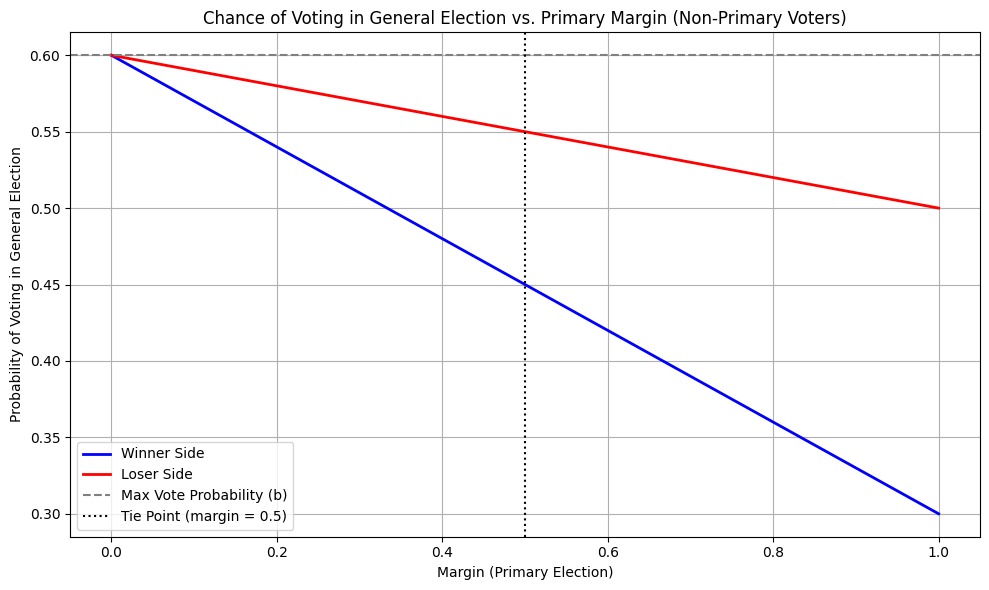

In [8]:
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b = 0.6          # max vote probability at tie
m1 = 0.3      # steeper slope for winner
m2 = 0.1         # flatter slope for loser

# Calculate probabilities
prob_winner = b - m1 * margins
prob_loser = b - m2 * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_winner, label="Winner Side", color='blue', linewidth=2)
plt.plot(margins, prob_loser, label="Loser Side", color='red', linewidth=2)
plt.axhline(b, color='gray', linestyle='--', label="Max Vote Probability (b)")
plt.axvline(0.5, color='black', linestyle=':', label="Tie Point (margin = 0.5)")

# Labels and titles
plt.title("Chance of Voting in General Election vs. Primary Margin (Non-Primary Voters)")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Parameters
# m1: winner, m2: loser
total_primary = len(primary_votes)
dem_count = np.sum(primary_votes == 'Democrat')
rep_count = total_primary - dem_count

margin = abs(dem_count - rep_count) / total_primary
    
prob_if_winner = b - m1 * margin
prob_if_loser = b - m2 * margin


print(f"Primary margin: {margin:.2f}")
print(f"Estimated probability of voting in general (non-primary voters) for winners: {prob_if_winner:.2%}")
print(f"Estimated probability of voting in general (non-primary voters) for losers: {prob_if_loser:.2%}")




Primary margin: 0.83
Estimated probability of voting in general (non-primary voters) for winners: 35.20%
Estimated probability of voting in general (non-primary voters) for losers: 51.73%


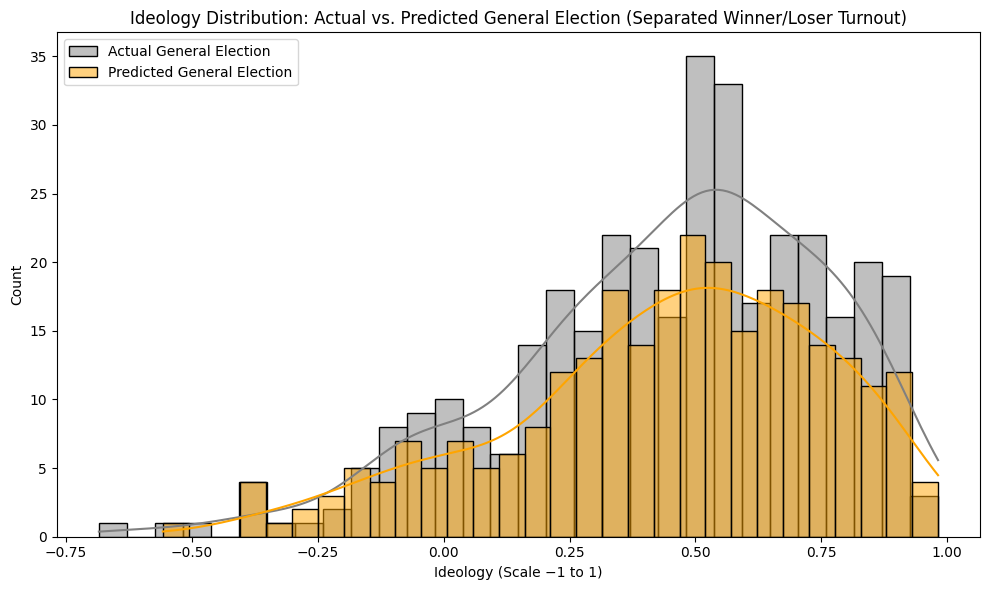

In [10]:
# Split the voters into winners and losers based on their vote
non_primary_indices = np.setdiff1d(np.arange(num_total_voters), primary_ideology_indices)
non_primary_ideologies = population_ideologies[non_primary_indices]
non_primary_votes = np.where(non_primary_ideologies <= 0, 'Democrat', 'Republican')

# Identify indices of winner and loser voters
winner = 'Democrat' if dem_count > rep_count else 'Republican'
winner_mask = non_primary_votes == winner
loser_mask = ~winner_mask

# Simulate general turnout separately using b, m1, m2 logic
general_voted = np.zeros_like(non_primary_votes, dtype=int)
general_voted[winner_mask] = np.random.binomial(n=1, p=prob_if_winner, size=np.sum(winner_mask)) # bernoulli trial for winners
general_voted[loser_mask] = np.random.binomial(n=1, p=prob_if_loser, size=np.sum(loser_mask))   # bernoulli trial for losers
# general_voted[winner_mask] = prob_if_winner
# general_voted[loser_mask] = prob_if_loser

# Collect ideologies of predicted general election participants (non-primary voters only)
predicted_non_primary_ideologies = non_primary_ideologies[general_voted == 1]

# Combine with primary voters (who always vote again)
general_pred_ideologies = np.concatenate([
    primary_ideologies,
    predicted_non_primary_ideologies
])

# Plot final comparison
plt.figure(figsize=(10, 6))
sns.histplot(general_ideologies, kde=True, color='gray', label='Actual General Election', bins=30, alpha=0.5)
sns.histplot(general_pred_ideologies, kde=True, color='orange', label='Predicted General Election', bins=30, alpha=0.5)

plt.title("Ideology Distribution: Actual vs. Predicted General Election (Separated Winner/Loser Turnout)")
plt.xlabel("Ideology (Scale −1 to 1)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
non_primary_ideologies[general_voted == 1]

array([ 0.23841275,  0.72373454,  0.27544569,  0.91212232,  0.61990539,
        0.46558874,  0.00469476,  0.18663109,  0.36535473,  0.67197007,
       -0.37797287,  0.05065162,  0.18124462,  0.72105981,  0.48571172,
        0.7395807 ,  0.07790995, -0.11904164,  0.66751997, -0.07273869,
       -0.00261854,  0.65438832,  0.45988861, -0.09788881,  0.48874446,
        0.50564876,  0.40382591,  0.24138835,  0.67267372,  0.88299331,
        0.05237152,  0.45737241,  0.8792914 ,  0.12731566,  0.47895604,
        0.43465052,  0.94256503,  0.44342023,  0.8077318 , -0.16243435,
        0.53631783,  0.30139378,  0.98165853,  0.29558082,  0.79931301,
        0.53296274,  0.02031301, -0.0506645 ,  0.2567636 ,  0.36772483,
        0.52363275,  0.20979128, -0.27344654,  0.44795588,  0.49534082,
        0.73310932,  0.43446756,  0.48394167,  0.46027514,  0.68802686,
        0.30763218,  0.22702401,  0.51277138,  0.34653597,  0.62289539,
       -0.06239065,  0.8753654 ,  0.61386924,  0.91074306,  0.79